# 🏋️ Notebook 04 — Model Training
**Chicago Crime ML Pipeline**

Trains multiple models for all 3 tasks using preprocessed data from `03_preprocessing.ipynb`.

| Task | Type | Models Trained |
|---|---|---|
| 1 — Arrest Prediction | Binary Classification | Logistic Regression, Random Forest, Gradient Boosting |
| 2 — Crime Type Prediction | Multi-class Classification | Logistic Regression, Random Forest, Gradient Boosting |
| 3 — Crime Count per Area | Regression | Ridge, Random Forest Regressor, Gradient Boosting Regressor |

Each model is trained with **cross-validation** on the training set, validated on the val set, and the best model per task is saved.

> **Next notebook:** `05_evaluation_comparison.ipynb`

---
## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, json, time, joblib

# Enable experimental feature (required for sklearn 0.24)
from sklearn.experimental import enable_hist_gradient_boosting  

# Scikit-learn models
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

---
## 2. Load Preprocessed Data

In [2]:
# ⚡ Config guard — ensures variables are defined even if cells run out of order
DATA_DIR     = globals().get('DATA_DIR',     'ml_data')
MODEL_DIR    = globals().get('MODEL_DIR',    'ml_models')
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
CV_FOLDS     = globals().get('CV_FOLDS',     3)
os.makedirs(MODEL_DIR, exist_ok=True)

def load_task(task_name):
    data = np.load(f'{DATA_DIR}/{task_name}_preprocessed.npz', allow_pickle=True)
    with open(f'{DATA_DIR}/{task_name}_meta.json') as f:
        meta = json.load(f)
    return (
        data['X_train'], data['X_val'], data['X_test'],
        data['y_train'], data['y_val'], data['y_test'],
        meta
    )

X_tr1, X_v1, X_te1, y_tr1, y_v1, y_te1, meta1 = load_task('task1')
X_tr2, X_v2, X_te2, y_tr2, y_v2, y_te2, meta2 = load_task('task2')
X_tr3, X_v3, X_te3, y_tr3, y_v3, y_te3, meta3 = load_task('task3')

for name, meta in [('Task 1', meta1), ('Task 2', meta2), ('Task 3', meta3)]:
    print(f"{name} | type: {meta['task_type']} | train: {meta['train_size']:,} "
          f"| val: {meta['val_size']:,} | test: {meta['test_size']:,} "
          f"| features: {meta['n_features']}")

Task 1 | type: classification | train: 84,900 | val: 18,000 | test: 18,000 | features: 23
Task 2 | type: classification | train: 172,070 | val: 18,000 | test: 18,000 | features: 21
Task 3 | type: regression | train: 83,398 | val: 17,871 | test: 17,871 | features: 19


---
## 3. Training Utilities

In [3]:
def train_and_evaluate_classifiers(models, X_train, y_train, X_val, y_val,
                                    task_name, n_classes=2):
    """
    Train each classifier, run CV, evaluate on val set.
    Returns a results dict and the best model.
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    results = {}
    best_score, best_model, best_name = -np.inf, None, None

    for name, model in models.items():
        print(f'  Training {name}...', end=' ', flush=True)
        t0 = time.time()

        # Cross-validation on training set
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=cv,
            scoring='f1_weighted', n_jobs=1
        )

        # Fit on full training set
        model.fit(X_train, y_train)
        elapsed = time.time() - t0

        # Validate
        y_pred = model.predict(X_val)
        acc    = accuracy_score(y_val, y_pred)
        f1     = f1_score(y_val, y_pred, average='weighted')

        # ROC-AUC (binary only)
        auc = None
        if n_classes == 2 and hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_prob)

        results[name] = {
            'cv_f1_mean' : cv_scores.mean(),
            'cv_f1_std'  : cv_scores.std(),
            'val_acc'    : acc,
            'val_f1'     : f1,
            'val_auc'    : auc,
            'train_time' : elapsed,
            'model'      : model
        }

        # Fixed print line for AUC formatting
        auc_str = f"{auc:.4f}" if auc is not None else "N/A"
        print(
            f"CV F1: {cv_scores.mean():.4f}±{cv_scores.std():.4f}  "
            f"Val Acc: {acc:.4f}  "
            f"Val F1: {f1:.4f}  "
            f"AUC: {auc_str:>6}  "
            f"Time: {elapsed:.1f}s"
        )

        if f1 > best_score:
            best_score, best_model, best_name = f1, model, name

    print(f'\n  🏆 Best model for {task_name}: {best_name} (Val F1={best_score:.4f})')
    return results, best_model, best_name

In [4]:
def train_and_evaluate_regressors(models, X_train, y_train, X_val, y_val, task_name):
    """
    Train each regressor, run CV, evaluate on val set.
    Returns a results dict and the best model.
    """
    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    results = {}
    best_score, best_model, best_name = np.inf, None, None

    for name, model in models.items():
        print(f'  Training {name}...', end=' ', flush=True)
        t0 = time.time()

        # Cross-validation (neg RMSE)
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=cv,
            scoring='neg_root_mean_squared_error', n_jobs=1
        )
        cv_rmse = -cv_scores  # positive RMSE

        # Fit on full training set
        model.fit(X_train, y_train)
        elapsed = time.time() - t0

        # Validate
        y_pred    = model.predict(X_val)
        val_rmse  = np.sqrt(mean_squared_error(y_val, y_pred))
        val_mae   = mean_absolute_error(y_val, y_pred)
        val_r2    = r2_score(y_val, y_pred)

        results[name] = {
            'cv_rmse_mean' : cv_rmse.mean(),
            'cv_rmse_std'  : cv_rmse.std(),
            'val_rmse'     : val_rmse,
            'val_mae'      : val_mae,
            'val_r2'       : val_r2,
            'train_time'   : elapsed,
            'model'        : model
        }

        print(
            f"CV RMSE: {cv_rmse.mean():.4f}±{cv_rmse.std():.4f}  "
            f"Val RMSE: {val_rmse:.4f}  Val MAE: {val_mae:.4f}  "
            f"Val R²: {val_r2:.4f}  Time: {elapsed:.1f}s"
        )

        if val_rmse < best_score:
            best_score, best_model, best_name = val_rmse, model, name

    print(f'\n  🏆 Best model for {task_name}: {best_name} (Val RMSE={best_score:.4f})')
    return results, best_model, best_name


print('Regressor training function defined ✅')

Regressor training function defined ✅


---
## 4. Task 1 — Arrest Prediction (Binary Classification)

In [5]:
print('\n🔵 TASK 1 — Arrest Prediction')
print('=' * 70)

models_t1 = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=10,  # ⚡ 200→100 trees
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1
    ),
    'Gradient Boosting': HistGradientBoostingClassifier(  # ⚡ 10-30x faster than GBC
        max_iter=100, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE
    )
}

res_t1, best_t1, best_name_t1 = train_and_evaluate_classifiers(
    models_t1, X_tr1, y_tr1, X_v1, y_v1,
    task_name='Task 1 (Arrest)', n_classes=2
)

# Save best model
joblib.dump(best_t1, f'{MODEL_DIR}/task1_best_model.pkl')
print(f'  ✅ Best model saved → {MODEL_DIR}/task1_best_model.pkl')


🔵 TASK 1 — Arrest Prediction
  Training Logistic Regression... CV F1: 0.7654±0.0019  Val Acc: 0.7657  Val F1: 0.7626  AUC: 0.8496  Time: 0.7s
  Training Random Forest... CV F1: 0.7823±0.0015  Val Acc: 0.7923  Val F1: 0.7865  AUC: 0.8800  Time: 24.0s
  Training Gradient Boosting... CV F1: 0.8019±0.0011  Val Acc: 0.8068  Val F1: 0.8037  AUC: 0.8876  Time: 5.3s

  🏆 Best model for Task 1 (Arrest): Gradient Boosting (Val F1=0.8037)
  ✅ Best model saved → ml_models/task1_best_model.pkl


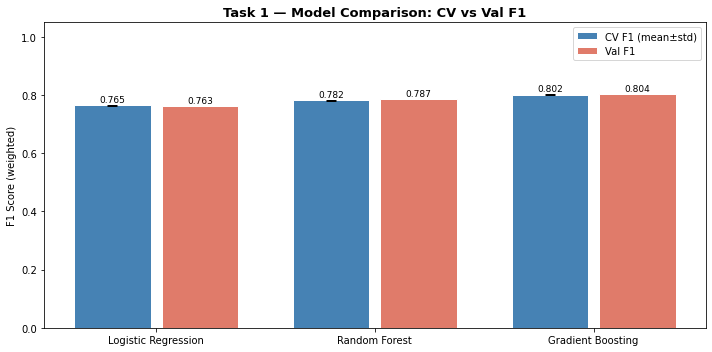

In [6]:
# ── CV score comparison — Task 1 ──────────────────────────────
names_t1  = list(res_t1.keys())
means_t1  = [res_t1[n]['cv_f1_mean'] for n in names_t1]
stds_t1   = [res_t1[n]['cv_f1_std']  for n in names_t1]
val_f1_t1 = [res_t1[n]['val_f1']     for n in names_t1]

x = np.arange(len(names_t1))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, means_t1, 0.35, yerr=stds_t1, capsize=5,
               label='CV F1 (mean±std)', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + 0.2, val_f1_t1, 0.35,
               label='Val F1', color='#e07b6a', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(names_t1)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (weighted)')
ax.set_title('Task 1 — Model Comparison: CV vs Val F1', fontweight='bold', fontsize=13)
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/04_task1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Task 2 — Crime Type Prediction (Multi-class Classification)

In [7]:
print('\n🟢 TASK 2 — Crime Type Prediction')
print('=' * 70)

n_classes_t2 = len(np.unique(y_tr2))
print(f'  Number of classes: {n_classes_t2}')

models_t2 = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        multi_class='multinomial', solver='lbfgs',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=15, min_samples_leaf=5,  # ⚡ 200→100 trees
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1
    ),
    'Gradient Boosting': HistGradientBoostingClassifier(  # ⚡ 10-30x faster than GBC
        max_iter=100, max_depth=6, learning_rate=0.08,
        random_state=RANDOM_STATE
    )
}

res_t2, best_t2, best_name_t2 = train_and_evaluate_classifiers(
    models_t2, X_tr2, y_tr2, X_v2, y_v2,
    task_name='Task 2 (Crime Type)', n_classes=n_classes_t2
)

joblib.dump(best_t2, f'{MODEL_DIR}/task2_best_model.pkl')
print(f'  ✅ Best model saved → {MODEL_DIR}/task2_best_model.pkl')


🟢 TASK 2 — Crime Type Prediction
  Number of classes: 10
  Training Logistic Regression... CV F1: 0.2260±0.0007  Val Acc: 0.2787  Val F1: 0.2209  AUC:    N/A  Time: 19.3s
  Training Random Forest... CV F1: 0.4634±0.0013  Val Acc: 0.3977  Val F1: 0.3744  AUC:    N/A  Time: 89.5s
  Training Gradient Boosting... CV F1: 0.4592±0.0021  Val Acc: 0.4621  Val F1: 0.4242  AUC:    N/A  Time: 69.5s

  🏆 Best model for Task 2 (Crime Type): Gradient Boosting (Val F1=0.4242)
  ✅ Best model saved → ml_models/task2_best_model.pkl


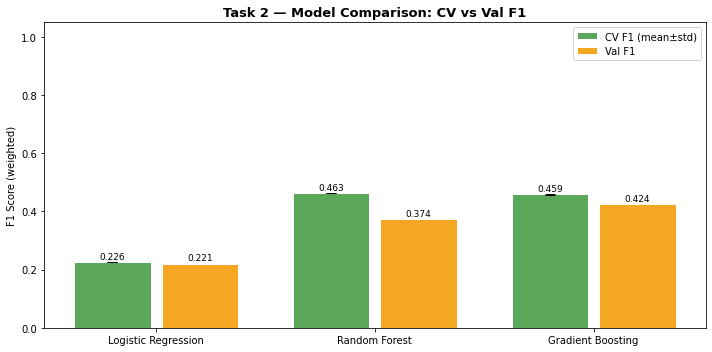

In [8]:
# ── CV score comparison — Task 2 ──────────────────────────────
names_t2  = list(res_t2.keys())
means_t2  = [res_t2[n]['cv_f1_mean'] for n in names_t2]
stds_t2   = [res_t2[n]['cv_f1_std']  for n in names_t2]
val_f1_t2 = [res_t2[n]['val_f1']     for n in names_t2]

x = np.arange(len(names_t2))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, means_t2, 0.35, yerr=stds_t2, capsize=5,
               label='CV F1 (mean±std)', color='#5ba85b', edgecolor='white')
bars2 = ax.bar(x + 0.2, val_f1_t2, 0.35,
               label='Val F1', color='#f5a623', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(names_t2)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (weighted)')

ax.set_title('Task 2 — Model Comparison: CV vs Val F1', fontweight='bold', fontsize=13)
ax.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/04_task2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Task 3 — Crime Count per Area (Regression)

In [9]:
print('\n🔴 TASK 3 — Crime Count Regression')
print('=' * 70)

# Log-transform target to reduce skew
y_tr3_log = np.log1p(y_tr3)
y_v3_log  = np.log1p(y_v3)

models_t3 = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_leaf=5,  # ⚡ 200→100 trees
        random_state=RANDOM_STATE, n_jobs=1
    ),
    'Gradient Boosting': HistGradientBoostingRegressor(  # ⚡ 10-30x faster than GBR
        max_iter=100, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE
    )
}

res_t3, best_t3, best_name_t3 = train_and_evaluate_regressors(
    models_t3, X_tr3, y_tr3_log, X_v3, y_v3_log,
    task_name='Task 3 (Crime Count)'
)

joblib.dump(best_t3, f'{MODEL_DIR}/task3_best_model.pkl')
print(f'  ✅ Best model saved → {MODEL_DIR}/task3_best_model.pkl')
print('  ℹ️  Note: models trained on log1p(CrimeCount) — exponentiate predictions with np.expm1()')


🔴 TASK 3 — Crime Count Regression
  Training Ridge Regression... CV RMSE: 0.3134±0.0011  Val RMSE: 0.3155  Val MAE: 0.2496  Val R²: 0.3801  Time: 0.1s
  Training Random Forest... CV RMSE: 0.3005±0.0008  Val RMSE: 0.2993  Val MAE: 0.2364  Val R²: 0.4422  Time: 96.1s
  Training Gradient Boosting... CV RMSE: 0.2978±0.0010  Val RMSE: 0.2980  Val MAE: 0.2377  Val R²: 0.4469  Time: 6.7s

  🏆 Best model for Task 3 (Crime Count): Gradient Boosting (Val RMSE=0.2980)
  ✅ Best model saved → ml_models/task3_best_model.pkl
  ℹ️  Note: models trained on log1p(CrimeCount) — exponentiate predictions with np.expm1()


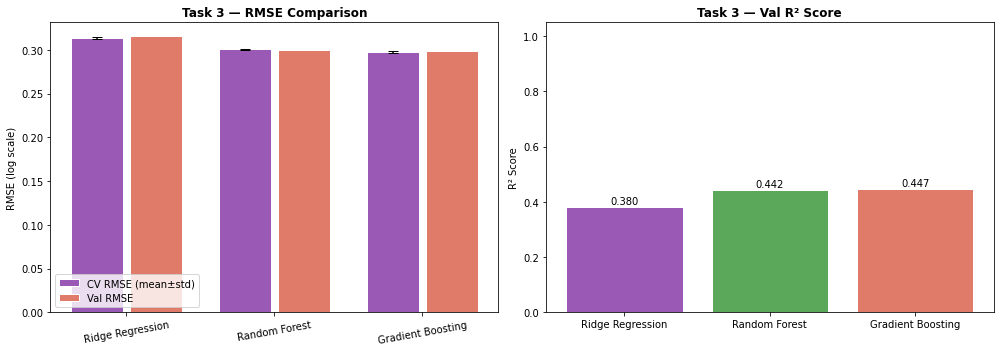

In [10]:
# ── CV RMSE comparison — Task 3 ───────────────────────────────
names_t3   = list(res_t3.keys())
means_t3   = [res_t3[n]['cv_rmse_mean'] for n in names_t3]
stds_t3    = [res_t3[n]['cv_rmse_std']  for n in names_t3]
val_rmse_t3 = [res_t3[n]['val_rmse']   for n in names_t3]
val_r2_t3   = [res_t3[n]['val_r2']     for n in names_t3]

x = np.arange(len(names_t3))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].bar(x - 0.2, means_t3, 0.35, yerr=stds_t3, capsize=5,
            label='CV RMSE (mean±std)', color='#9b59b6', edgecolor='white')
axes[0].bar(x + 0.2, val_rmse_t3, 0.35,
            label='Val RMSE', color='#e07b6a', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(names_t3, rotation=10)
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_title('Task 3 — RMSE Comparison', fontweight='bold')
axes[0].legend()

# R²
axes[1].bar(names_t3, val_r2_t3, color=['#9b59b6','#5ba85b','#e07b6a'], edgecolor='white')
axes[1].set_ylabel('R² Score')
axes[1].set_title('Task 3 — Val R² Score', fontweight='bold')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(val_r2_t3):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/04_task3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Training Time Comparison

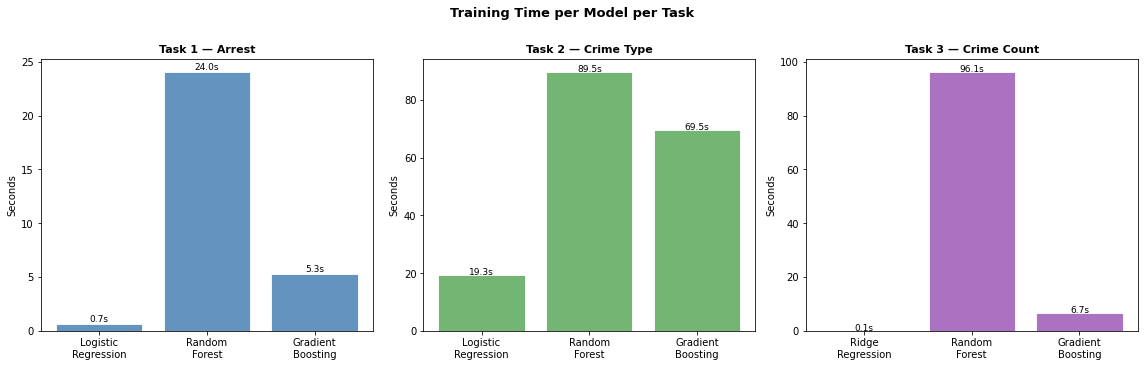

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

task_results = [
    ('Task 1 — Arrest', res_t1, 'steelblue'),
    ('Task 2 — Crime Type', res_t2, '#5ba85b'),
    ('Task 3 — Crime Count', res_t3, '#9b59b6'),
]

for ax, (title, res, color) in zip(axes, task_results):
    names = list(res.keys())
    times = [res[n]['train_time'] for n in names]
    short_names = [n.replace(' ', '\n') for n in names]
    bars = ax.bar(short_names, times, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Seconds')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                f'{h:.1f}s', ha='center', fontsize=9)

plt.suptitle('Training Time per Model per Task', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/04_training_times.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save All Results & Metadata

In [12]:
def serialize_results(res, task_type):
    """Strip non-serialisable model objects before saving to JSON."""
    out = {}
    for model_name, vals in res.items():
        out[model_name] = {k: v for k, v in vals.items() if k != 'model'}
        # Convert numpy types to native Python
        for k, v in out[model_name].items():
            if isinstance(v, (np.float32, np.float64)):
                out[model_name][k] = float(v)
            elif v is None:
                out[model_name][k] = None
    return out

training_summary = {
    'task1': {
        'best_model' : best_name_t1,
        'task_type'  : 'binary_classification',
        'results'    : serialize_results(res_t1, 'classification')
    },
    'task2': {
        'best_model' : best_name_t2,
        'task_type'  : 'multiclass_classification',
        'results'    : serialize_results(res_t2, 'classification')
    },
    'task3': {
        'best_model' : best_name_t3,
        'task_type'  : 'regression',
        'results'    : serialize_results(res_t3, 'regression')
    }
}

with open(f'{MODEL_DIR}/training_summary.json', 'w') as f:
    json.dump(training_summary, f, indent=2)

# Also save all models (not just best)
for name, model in models_t1.items():
    joblib.dump(model, f"{MODEL_DIR}/task1_{name.replace(' ', '_').lower()}.pkl")
for name, model in models_t2.items():
    joblib.dump(model, f"{MODEL_DIR}/task2_{name.replace(' ', '_').lower()}.pkl")
for name, model in models_t3.items():
    joblib.dump(model, f"{MODEL_DIR}/task3_{name.replace(' ', '_').lower()}.pkl")

print('All models saved to ml_models/')
print(' training_summary.json saved')

All models saved to ml_models/
 training_summary.json saved


---
## 9. Summary

In [13]:
print('=' * 70)
print('            NOTEBOOK 04 — MODEL TRAINING COMPLETE')
print('=' * 70)

print(f"\n  Task 1 — Arrest Prediction (Binary Classification)")
print(f"  {'Model':<25} {'CV F1':>8} {'Val F1':>8} {'Val AUC':>9}")
print(f"  {'-'*55}")
for n in res_t1:
    r = res_t1[n]
    auc_str = f"{r['val_auc']:.4f}" if r['val_auc'] else '  N/A '
    marker = ' 🏆' if n == best_name_t1 else ''
    print(f"  {n:<25} {r['cv_f1_mean']:>8.4f} {r['val_f1']:>8.4f} {auc_str:>9}{marker}")

print(f"\n  Task 2 — Crime Type Prediction (Multi-class Classification)")
print(f"  {'Model':<25} {'CV F1':>8} {'Val F1':>8}")
print(f"  {'-'*45}")
for n in res_t2:
    r = res_t2[n]
    marker = ' 🏆' if n == best_name_t2 else ''
    print(f"  {n:<25} {r['cv_f1_mean']:>8.4f} {r['val_f1']:>8.4f}{marker}")

print(f"\n  Task 3 — Crime Count per Area (Regression)")
print(f"  {'Model':<25} {'CV RMSE':>9} {'Val RMSE':>9} {'Val R²':>8}")
print(f"  {'-'*55}")
for n in res_t3:
    r = res_t3[n]
    marker = ' 🏆' if n == best_name_t3 else ''
    print(f"  {n:<25} {r['cv_rmse_mean']:>9.4f} {r['val_rmse']:>9.4f} {r['val_r2']:>8.4f}{marker}")

print()
print('   Models saved to ml_models/')
print('    Next: 05_evaluation_comparison.ipynb')
print('=' * 70)

            NOTEBOOK 04 — MODEL TRAINING COMPLETE

  Task 1 — Arrest Prediction (Binary Classification)
  Model                        CV F1   Val F1   Val AUC
  -------------------------------------------------------
  Logistic Regression         0.7654   0.7626    0.8496
  Random Forest               0.7823   0.7865    0.8800
  Gradient Boosting           0.8019   0.8037    0.8876 🏆

  Task 2 — Crime Type Prediction (Multi-class Classification)
  Model                        CV F1   Val F1
  ---------------------------------------------
  Logistic Regression         0.2260   0.2209
  Random Forest               0.4634   0.3744
  Gradient Boosting           0.4592   0.4242 🏆

  Task 3 — Crime Count per Area (Regression)
  Model                       CV RMSE  Val RMSE   Val R²
  -------------------------------------------------------
  Ridge Regression             0.3134    0.3155   0.3801
  Random Forest                0.3005    0.2993   0.4422
  Gradient Boosting            0.2978   

In [14]:
!python -m pip show joblib

Name: joblib
Version: 1.1.1
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: Gael Varoquaux
Author-email: gael.varoquaux@normalesup.org
License: BSD
Location: d:\new folder\envs\booksenv\lib\site-packages
Requires: 
Required-by: imbalanced-learn, scikit-learn
